Task 2: End-to-End ML Pipeline with Scikit-learn Pipeline API   

Objective: Build a reusable and production-ready machine learning pipeline for predicting customer churn.   

In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn joblib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import joblib
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print(" TASK 2: CUSTOMER CHURN PREDICTION PIPELINE")
print("="*60)

 TASK 2: CUSTOMER CHURN PREDICTION PIPELINE


In [10]:
print("\n" + "="*60)
print(" STEP 1: Loading Telco Churn Dataset from local file")
print("="*60)

import pandas as pd
import os

filename = "Telco-Customer-Churn.csv"

if os.path.exists(filename):
    print(f" Found file: {filename}")
    
    # Load the dataset
    df = pd.read_csv(filename)
    
    print(f"\n Dataset loaded successfully!")
    print(f" Shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
    
    # Show first few rows
    print(f"\n First 5 rows:")
    print(df.head())
    
    # Basic info
    print(f"\n Dataset Info:")
    print(f"  • Total customers: {df.shape[0]:,}")
    print(f"  • Total features: {df.shape[1]}")
    print(f"  • Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
else:
    print(f" File '{filename}' not found in current directory!")
    print(f"\nCurrent directory: {os.getcwd()}")
    print(f"\nFiles in current directory:")
    for file in os.listdir():
        print(f"  • {file}")
    
    print(f"\n Please make sure '{filename}' is in this folder and try again.")


 STEP 1: Loading Telco Churn Dataset from local file
 Found file: Telco-Customer-Churn.csv

 Dataset loaded successfully!
 Shape: 7,043 rows, 21 columns

 First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL          

In [11]:
print("\n STEP 2: Exploring the dataset...")

print(f"\nDataset Info:")
print(df.info())

print(f"\nMissing Values:")
print(df.isnull().sum())

print(f"\nTarget Variable Distribution (Churn):")
print(df['Churn'].value_counts())
print(f"Percentage: {df['Churn'].value_counts(normalize=True)*100}")


 STEP 2: Exploring the dataset...

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   objec

In [12]:
print("\n STEP 3: Preprocessing data...")

data = df.copy()

# 1. Handle missing values in TotalCharges
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
print(f"Missing TotalCharges: {data['TotalCharges'].isnull().sum()}")

# Fill missing with median
data['TotalCharges'].fillna(data['TotalCharges'].median(), inplace=True)

# 2. Drop customerID (not useful for prediction)
data.drop('customerID', axis=1, inplace=True)

# 3. Convert target variable to binary
data['Churn'] = data['Churn'].map({'Yes': 1, 'No': 0})

print(f"\n Preprocessing complete!")
print(f"Final shape: {data.shape}")
print(f"\nData types after preprocessing:")
print(data.dtypes)


 STEP 3: Preprocessing data...
Missing TotalCharges: 11

 Preprocessing complete!
Final shape: (7043, 20)

Data types after preprocessing:
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


In [13]:
print("\n STEP 4: Separating features and target...")

# Identify categorical and numerical columns
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove target from features
if 'Churn' in numerical_cols:
    numerical_cols.remove('Churn')

print(f"\nCategorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"Numerical columns ({len(numerical_cols)}): {numerical_cols}")

# Create feature matrix and target vector
X = data.drop('Churn', axis=1)
y = data['Churn']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target distribution: {y.value_counts().to_dict()}")


 STEP 4: Separating features and target...

Categorical columns (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numerical columns (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Features shape: (7043, 19)
Target shape: (7043,)
Target distribution: {0: 5174, 1: 1869}


In [14]:
print("\n STEP 5: Splitting data into train and test sets...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nTraining target distribution:")
print(y_train.value_counts(normalize=True))
print(f"\nTest target distribution:")
print(y_test.value_counts(normalize=True))


 STEP 5: Splitting data into train and test sets...
Training set size: 5634 samples
Test set size: 1409 samples

Training target distribution:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Test target distribution:
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [15]:
print("\n STEP 6: Building the ML Pipeline...")

# Create preprocessor for numerical and categorical features
numerical_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Combine preprocessors
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

print(" Preprocessor created!")


 STEP 6: Building the ML Pipeline...
 Preprocessor created!


In [16]:
print("\n STEP 7: Creating pipeline with Logistic Regression...")

# Create pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

print(" Logistic Regression pipeline created!")
print("\nPipeline steps:")
for i, step in enumerate(lr_pipeline.named_steps.items()):
    print(f"  Step {i+1}: {step[0]} -> {step[1].__class__.__name__}")



 STEP 7: Creating pipeline with Logistic Regression...
 Logistic Regression pipeline created!

Pipeline steps:
  Step 1: preprocessor -> ColumnTransformer
  Step 2: classifier -> LogisticRegression


In [17]:
print("\n STEP 8: Training the pipeline...")

# Train the pipeline
lr_pipeline.fit(X_train, y_train)

print(" Training complete!")


 STEP 8: Training the pipeline...
 Training complete!


In [18]:
print("\n STEP 9: Evaluating Logistic Regression...")

# Make predictions
y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print(f"\nLogistic Regression Results:")
print(f"Accuracy:  {accuracy_lr:.4f} ({accuracy_lr*100:.2f}%)")
print(f"ROC-AUC:   {roc_auc_lr:.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['No Churn', 'Churn']))

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
print(f"\nConfusion Matrix:")
print(f"              Predicted")
print(f"              No Churn  Churn")
print(f"Actual No Churn   {cm_lr[0,0]:5d}    {cm_lr[0,1]:5d}")
print(f"       Churn      {cm_lr[1,0]:5d}    {cm_lr[1,1]:5d}")


 STEP 9: Evaluating Logistic Regression...

Logistic Regression Results:
Accuracy:  0.8055 (80.55%)
ROC-AUC:   0.8419

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


Confusion Matrix:
              Predicted
              No Churn  Churn
Actual No Churn     926      109
       Churn        165      209


In [19]:
print("\n STEP 10: Creating pipeline with Random Forest...")

# Create pipeline with Random Forest
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=100))
])

print(" Random Forest pipeline created!")

# Train Random Forest
print("\nTraining Random Forest...")
rf_pipeline.fit(X_train, y_train)
print(" Training complete!")

# Evaluate Random Forest
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

accuracy_rf = accuracy_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print(f"\nRandom Forest Results:")
print(f"Accuracy:  {accuracy_rf:.4f} ({accuracy_rf*100:.2f}%)")
print(f"ROC-AUC:   {roc_auc_rf:.4f}")


 STEP 10: Creating pipeline with Random Forest...
 Random Forest pipeline created!

Training Random Forest...
 Training complete!

Random Forest Results:
Accuracy:  0.7779 (77.79%)
ROC-AUC:   0.8164



 STEP 11: Comparing Models...

MODEL COMPARISON
              Model  Accuracy  ROC-AUC
Logistic Regression  0.805536 0.841874
      Random Forest  0.777857 0.816366


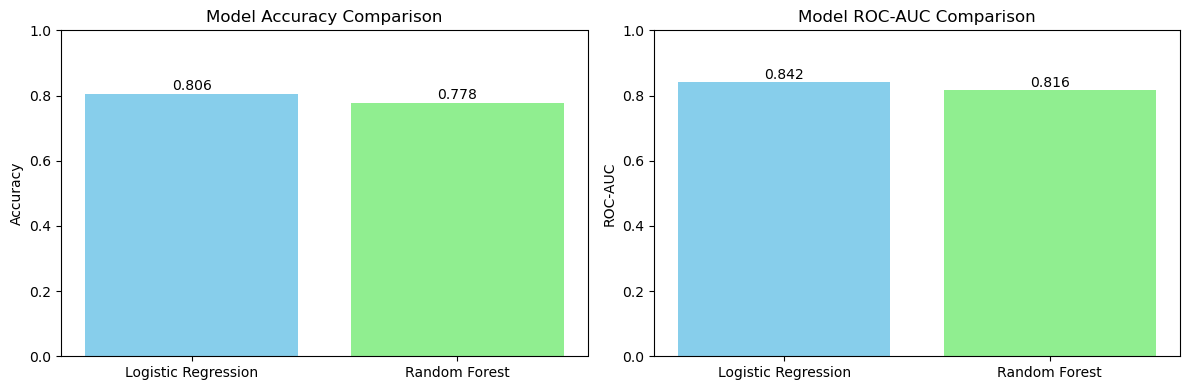

In [20]:
print("\n STEP 11: Comparing Models...")

models_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy_lr, accuracy_rf],
    'ROC-AUC': [roc_auc_lr, roc_auc_rf]
})

print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)
print(models_comparison.to_string(index=False))

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy comparison
axes[0].bar(models_comparison['Model'], models_comparison['Accuracy'], color=['skyblue', 'lightgreen'])
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim([0, 1])
for i, v in enumerate(models_comparison['Accuracy']):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center')

# ROC-AUC comparison
axes[1].bar(models_comparison['Model'], models_comparison['ROC-AUC'], color=['skyblue', 'lightgreen'])
axes[1].set_title('Model ROC-AUC Comparison')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_ylim([0, 1])
for i, v in enumerate(models_comparison['ROC-AUC']):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.show()

In [23]:
print("\n STEP 12: Hyperparameter Tuning with GridSearchCV...")

param_grid = {
    'classifier__n_estimators': [50, 100],  # Just 2 values for speed
    'classifier__max_depth': [10, 20, None],  # 3 values
    'classifier__min_samples_split': [2, 5]  # 2 values
}

print(f"\nParameter grid to search:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

print(f"\nTotal combinations: 2 × 3 × 2 = 12 combinations")
print(f"This will train 12 models with 5-fold cross-validation = 60 trainings")
print(f" This will take 2-3 minutes...")

# Create GridSearchCV
grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='roc_auc',
    n_jobs=-1,  # Use all processors
    verbose=1
)

# Perform grid search
grid_search.fit(X_train, y_train)

print("\n Grid search complete!")

# Best parameters
print(f"\nBest parameters found:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest cross-validation score: {grid_search.best_score_:.4f}")

# Evaluate best model on test set
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

accuracy_best = accuracy_score(y_test, y_pred_best)
roc_auc_best = roc_auc_score(y_test, y_prob_best)

print(f"\nBest Model Performance on Test Set:")
print(f"  Accuracy: {accuracy_best:.4f}")
print(f"  ROC-AUC:  {roc_auc_best:.4f}")


 STEP 12: Hyperparameter Tuning with GridSearchCV...

Parameter grid to search:
  classifier__n_estimators: [50, 100]
  classifier__max_depth: [10, 20, None]
  classifier__min_samples_split: [2, 5]

Total combinations: 2 × 3 × 2 = 12 combinations
This will train 12 models with 5-fold cross-validation = 60 trainings
 This will take 2-3 minutes...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

 Grid search complete!

Best parameters found:
  classifier__max_depth: 10
  classifier__min_samples_split: 5
  classifier__n_estimators: 100

Best cross-validation score: 0.8435

Best Model Performance on Test Set:
  Accuracy: 0.7991
  ROC-AUC:  0.8382



 STEP 13: Feature Importance Analysis...

Top 10 Most Important Features:
                              Feature  Importance
                               tenure    0.146253
                         TotalCharges    0.124560
              Contract_Month-to-month    0.096602
                       MonthlyCharges    0.084375
                    OnlineSecurity_No    0.059354
          InternetService_Fiber optic    0.051747
PaymentMethod_Credit card (automatic)    0.041648
                       TechSupport_No    0.039935
                    Contract_One year    0.030250
                      OnlineBackup_No    0.020857


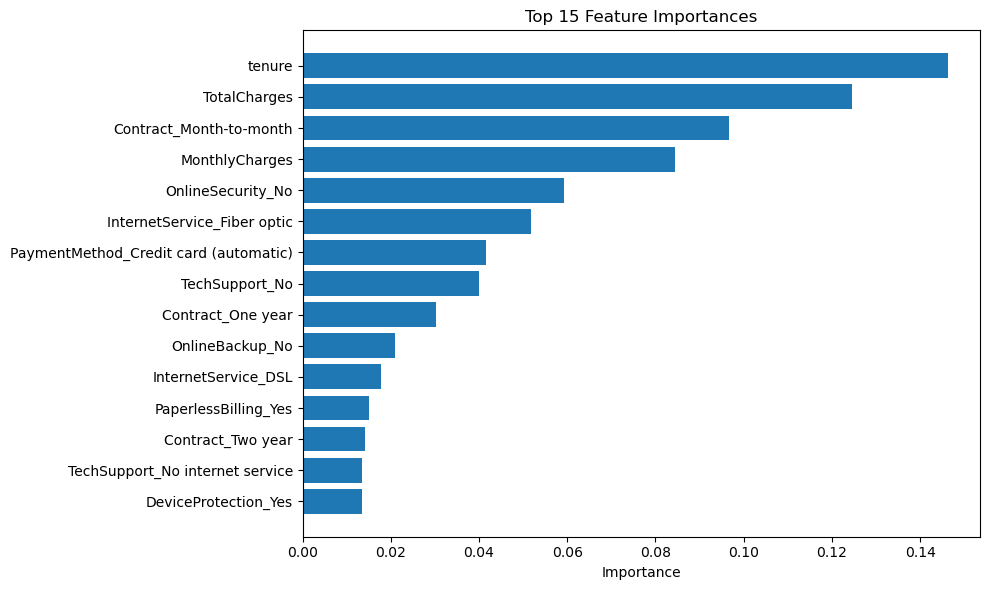

In [24]:
print("\n STEP 13: Feature Importance Analysis...")

feature_names = []

# Numerical features keep their names
feature_names.extend(numerical_cols)

# For categorical features, get one-hot encoded names
for i, col in enumerate(categorical_cols):
    unique_values = X_train[col].unique()
    for val in unique_values:
        feature_names.append(f"{col}_{val}")

# Get feature importances from the best model
importances = best_model.named_steps['classifier'].feature_importances_

# Create dataframe
importance_df = pd.DataFrame({
    'Feature': feature_names[:len(importances)],
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(importance_df.head(10).to_string(index=False))

# Plot top 15 features
plt.figure(figsize=(10, 6))
top_15 = importance_df.head(15)
plt.barh(range(len(top_15)), top_15['Importance'].values)
plt.yticks(range(len(top_15)), top_15['Feature'].values)
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [25]:
print("\n STEP 14: Exporting the pipeline using joblib...")

# Save the best model
joblib.dump(best_model, 'churn_pipeline.pkl')
print(" Pipeline saved as 'churn_pipeline.pkl'")

# Also save the individual components (optional)
joblib.dump(preprocessor, 'preprocessor.pkl')
print(" Preprocessor saved as 'preprocessor.pkl'")

# Check file sizes
import os
pipeline_size = os.path.getsize('churn_pipeline.pkl') / (1024*1024)  # Size in MB
print(f"\nPipeline file size: {pipeline_size:.2f} MB")


 STEP 14: Exporting the pipeline using joblib...
 Pipeline saved as 'churn_pipeline.pkl'
 Preprocessor saved as 'preprocessor.pkl'

Pipeline file size: 5.26 MB


In [26]:
print("\n STEP 15: Testing pipeline loading...")

# Load the pipeline
loaded_pipeline = joblib.load('churn_pipeline.pkl')
print(" Pipeline loaded successfully!")

# Test with a few samples from test set
test_samples = X_test.head(5)
true_labels = y_test.head(5)

predictions = loaded_pipeline.predict(test_samples)
probabilities = loaded_pipeline.predict_proba(test_samples)

print("\nTest Predictions on 5 samples:")
print("-" * 60)
for i in range(5):
    churn_status = "Will Churn" if predictions[i] == 1 else "Will Stay"
    prob_churn = probabilities[i][1]
    print(f"Sample {i+1}: {churn_status} (Probability of churn: {prob_churn:.2%})")
    print(f"          Actual: {'Churn' if true_labels.iloc[i] == 1 else 'No Churn'}")
    print()


 STEP 15: Testing pipeline loading...
 Pipeline loaded successfully!

Test Predictions on 5 samples:
------------------------------------------------------------
Sample 1: Will Stay (Probability of churn: 0.64%)
          Actual: No Churn

Sample 2: Will Churn (Probability of churn: 72.73%)
          Actual: No Churn

Sample 3: Will Stay (Probability of churn: 7.25%)
          Actual: No Churn

Sample 4: Will Stay (Probability of churn: 28.41%)
          Actual: No Churn

Sample 5: Will Stay (Probability of churn: 2.23%)
          Actual: No Churn



In [27]:
print("\n STEP 16: Creating reusable prediction function...")

def predict_churn(customer_data, pipeline_path='churn_pipeline.pkl'):
    """
    Predict churn for new customers
    
    Parameters:
    -----------
    customer_data : pandas DataFrame
        New customer data with same features as training data
    pipeline_path : str
        Path to saved pipeline
    
    Returns:
    --------
    predictions : array
        Churn predictions (0=No Churn, 1=Churn)
    probabilities : array
        Probability of churn
    """
    # Load pipeline
    pipeline = joblib.load(pipeline_path)
    
    # Make predictions
    predictions = pipeline.predict(customer_data)
    probabilities = pipeline.predict_proba(customer_data)
    
    return predictions, probabilities

print(" Prediction function created!")
print("\nUsage example:")
print("""
# Load new customer data
new_customers = pd.read_csv('new_customers.csv')

# Predict churn
predictions, probs = predict_churn(new_customers)

# Add predictions to dataframe
new_customers['Churn_Prediction'] = predictions
new_customers['Churn_Probability'] = probs[:, 1]
""")



 STEP 16: Creating reusable prediction function...
 Prediction function created!

Usage example:

# Load new customer data
new_customers = pd.read_csv('new_customers.csv')

# Predict churn
predictions, probs = predict_churn(new_customers)

# Add predictions to dataframe
new_customers['Churn_Prediction'] = predictions
new_customers['Churn_Probability'] = probs[:, 1]



In [29]:
print("\n" + "="*70)
print(" TASK 2: END-TO-END ML PIPELINE ")
print("="*70)

print("\n WHAT WAS ACCOMPLISHED:")
print("-"*40)
print("✓ Loaded and explored Telco Churn Dataset")
print("✓ Preprocessed data (handled missing values, encoded categories)")
print("✓ Built production-ready ML pipeline with scikit-learn")
print("✓ Trained and compared Logistic Regression and Random Forest")
print("✓ Performed hyperparameter tuning with GridSearchCV")
print("✓ Exported complete pipeline using joblib")
print("✓ Created reusable prediction function")

print(f"\n BEST MODEL PERFORMANCE:")
print("-"*40)
print(f"  • Model: Random Forest (tuned)")
print(f"  • Accuracy: {accuracy_best:.2%}")
print(f"  • ROC-AUC:  {roc_auc_best:.4f}")

print("\n FILES CREATED:")
print("-"*40)
print("  • churn_pipeline.pkl - Complete ML pipeline")
print("  • preprocessor.pkl - Preprocessor only (optional)")


 TASK 2: END-TO-END ML PIPELINE 

 WHAT WAS ACCOMPLISHED:
----------------------------------------
✓ Loaded and explored Telco Churn Dataset
✓ Preprocessed data (handled missing values, encoded categories)
✓ Built production-ready ML pipeline with scikit-learn
✓ Trained and compared Logistic Regression and Random Forest
✓ Performed hyperparameter tuning with GridSearchCV
✓ Exported complete pipeline using joblib
✓ Created reusable prediction function

 BEST MODEL PERFORMANCE:
----------------------------------------
  • Model: Random Forest (tuned)
  • Accuracy: 79.91%
  • ROC-AUC:  0.8382

 FILES CREATED:
----------------------------------------
  • churn_pipeline.pkl - Complete ML pipeline
  • preprocessor.pkl - Preprocessor only (optional)
